# Homework 1 Written Problems

In [90]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import functools
import matplotlib.pyplot as plt

### 1. Derive and implement discrete-time dynamics given continuous-time dynamics.
Consider the following continuous-time dynamically-extended simple unicycle model. This is a common model for mobile robots with differential drive.

$$
\dot{\mathbf{x}} = \begin{bmatrix}
    \dot{x} \\ \dot{y} \\ \dot{\theta} \\ \dot{v}
\end{bmatrix} = \begin{bmatrix}
    v\cos\theta \\ v\sin\theta \\ \omega \\ a
\end{bmatrix}, \quad u=(\omega, a)
$$

#### (a)
Write down the discrete-time dynamics $\mathbf{x}_{t+1} = f(\mathbf{x}_t, \mathbf{u}_t)$ using Euler integration with step size $\Delta t$.

    



The discrete time dynamics using Euler integration are
$$
\begin{bmatrix}
    x_{k+1}\\
    y_{k+1}\\
    \theta_{k+1}\\
    v_{k+1}
\end{bmatrix}
=
\begin{bmatrix}
    x_{k}\\
    y_{k}\\
    \theta_{k}\\
    v_{k}
\end{bmatrix}
+
\begin{bmatrix}
    v\cos\theta\\
    v\sin\theta\\
    \omega\\
    a
\end{bmatrix}
\Delta t
$$

#### (b)
Assuming zero-order hold over each time step of size $\Delta t$, write down the corresponding discrete-time dynamics $\mathbf{x}_{k+1} = f_\text{d}(\mathbf{x}_k, \mathbf{u}_k, t_k)$ by performing the integration analytically, where $f_\text{d}(\mathbf{x}_k, \mathbf{u}_k) = \mathbf{x}_k + \int_{t_k}^{t_k+\Delta t}f_\text{c}(\mathbf{x}(\tau), u(\tau), \tau)d\tau$ where $\mathbf{x}_k = \mathbf{x}(t_k)$, and $\mathbf{x}_{k+1} = \mathbf{x}(t_{k+1}) = \mathbf{x}(t_k + \Delta t)$. You may *verify* your results with your favorite software (e.g., Mathematica or Wolfram Alpha), but should outline the intermediate steps.

*Note: In your analytic discrete-time dynamics, you will encounter $\omega$ in the denominator of some expressions. In your code, you must handle cases when $\omega$ is equal to or very near zero to avoid numerical errors or division by zero. (Tip: Instead of using an `if` statement, you can use `jax.numpy.where` for better support of batched inputs.)* 
    - *Hint*: The theoretical analytic solution is well-behaved as $\omega \to 0$, but your code must take care with this limit.


### Answer:

Under zero-order hold, we assume $u(\tau)$ is constant over $\Delta t$, so $\omega(\tau) = \omega(t_k) = \omega$ and $a(\tau) = a(t_k) = a$.

The discrete-time dynamics are:
$Under zero-order hold, we assume $u(\tau)$ is constant over $\Delta t$, so $\omega(\tau) = \omega(t_k) = \omega$ and $a(\tau) = a(t_k) = a$. The discrete-time dynamics are:

$$\mathbf{x}_{k+1} = \mathbf{x}_k + \int_{t_k}^{t_{k+1}} f_c(\mathbf{x}(\tau), u(\tau), \tau)\, d\tau$$

Integrating $\dot{x}$ via integration by parts, with $u = v(\tau)$, $dv = \cos(\theta(\tau))\,d\tau$, $du = a\,d\tau$, $v = \frac{1}{\omega}\sin(\theta(\tau))$:

\begin{align*}
\int_{t_k}^{t_{k+1}} v(\tau)\cos(\theta(\tau))\,d\tau
&= \left[\frac{v(\tau)}{\omega}\sin(\theta(\tau))\right]_{t_k}^{t_{k+1}} - \int_{t_k}^{t_{k+1}} \frac{a}{\omega}\sin(\theta(\tau))\, d\tau \\
&= \frac{1}{\omega}\left[v(t_{k+1})\sin(\theta(t_{k+1})) - v(t_k)\sin(\theta(t_k))\right] + \left[\frac{a}{\omega^2}\cos\theta(\tau)\right]_{t_k}^{t_{k+1}} \\
&= \frac{1}{\omega}\left[v(t_{k+1})\sin(\theta(t_{k+1})) - v(t_k)\sin(\theta(t_k))\right] + \frac{a}{\omega^2}\left(\cos\theta(t_{k+1}) - \cos\theta(t_k)\right)
\end{align*}

$$\boxed{x_{k+1} = x_k + \frac{1}{\omega}\left[(v_k + a\Delta t)\sin(\theta_k + \omega\Delta t) - v_k\sin\theta_k\right] + \frac{a}{\omega^2}\left(\cos(\theta_k + \omega\Delta t) - \cos\theta_k\right)}$$

Integrating $\dot{y}$ via integration by parts, with $u = v(\tau)$, $dv = \sin(\theta(\tau))\,d\tau$, $du = a\,d\tau$, $v = -\frac{1}{\omega}\cos(\theta(\tau))$:

\begin{align*}
\int_{t_k}^{t_{k+1}} v(\tau)\sin(\theta(\tau))\,d\tau
&= \left[-\frac{v(\tau)}{\omega}\cos(\theta(\tau))\right]_{t_k}^{t_{k+1}} - \int_{t_k}^{t_{k+1}} \left(-\frac{a}{\omega}\right)\cos(\theta(\tau))\, d\tau \\
&= \frac{1}{\omega}\left[v(t_k)\cos(\theta(t_k)) - v(t_{k+1})\cos(\theta(t_{k+1}))\right] + \left[\frac{a}{\omega^2}\sin\theta(\tau)\right]_{t_k}^{t_{k+1}} \\
&= \frac{1}{\omega}\left[v(t_k)\cos(\theta(t_k)) - v(t_{k+1})\cos(\theta(t_{k+1}))\right] + \frac{a}{\omega^2}\left(\sin\theta(t_{k+1}) - \sin\theta(t_k)\right)
\end{align*}

$$\boxed{y_{k+1} = y_k - \frac{1}{\omega}\left[(v_k + a\Delta t)\cos(\theta_k + \omega\Delta t) - v_k\cos\theta_k\right] + \frac{a}{\omega^2}\left(\sin(\theta_k + \omega\Delta t) - \sin\theta_k\right)}$$

Integrating $\dot{\theta}$ and $\dot{v}$:

\begin{align*}
\int_{t_k}^{t_{k+1}} \omega\, d\tau &= \left[\omega\tau\right]_{t_k}^{t_{k+1}} = \omega\Delta t \qquad \Rightarrow \qquad \boxed{\theta_{k+1} = \theta_k + \omega_k \Delta t} \\[0.5em]
\int_{t_k}^{t_{k+1}} a\, d\tau &= a\Delta t \qquad \Rightarrow \qquad \boxed{v_{k+1} = v_k + a_k \Delta t}
\end{align*}

The final discrete time dynamics using ZOH are

$$
\begin{bmatrix}
    x_{k+1}\\
    y_{k+1}\\
    \theta_{k+1}\\
    v_{k+1}
\end{bmatrix}
=
\begin{bmatrix}
    x_{k}\\
    y_{k}\\
    \theta_{k}\\
    v_{k}
\end{bmatrix}
+
\begin{bmatrix}
    \dfrac{1}{\omega}\left((v_k+a\Delta t)\sin\theta'-v_k\sin\theta\right) + \dfrac{a}{\omega^2}(\cos\theta'-\cos\theta)\\[1em]
    -\dfrac{1}{\omega}\left((v_k+a\Delta t)\cos\theta'-v_k\cos\theta\right) + \dfrac{a}{\omega^2}(\sin\theta'-\sin\theta)\\[1em]
    \theta_k + \omega\Delta t\\[1em]
    v_{k}+a\Delta t
\end{bmatrix}
$$

where $\theta' = \theta_k + \omega\Delta t$.

#### (c)
Using your analytic expression from (a), analytically differentiate your expression to obtain the state and control jacobians of the discrete-time dynamics.

Using $\theta' = \theta_k + \omega\Delta t$, we differentiate each row of the dynamics equation with respect to each state variable and obtain the state jacobain:
$$
A_k = \begin{bmatrix}
1 & 0 & \dfrac{(v_k+a\Delta t)\cos\theta' - v_k\cos\theta_k}{\omega} - \dfrac{a(\sin\theta' - \sin\theta_k)}{\omega^2} & \dfrac{\sin\theta' - \sin\theta_k}{\omega} \\[1.2em]
0 & 1 & \dfrac{(v_k+a\Delta t)\sin\theta' - v_k\sin\theta_k}{\omega} + \dfrac{a(\cos\theta' - \cos\theta_k)}{\omega^2} & \dfrac{\cos\theta_k - \cos\theta'}{\omega} \\[1.2em]
0 & 0 & 1 & 0 \\[1em]
0 & 0 & 0 & 1
\end{bmatrix}
$$

Differentiating with respect to the control variables yields the control jacobian:

Using $\theta' = \theta_k + \omega\Delta t$:

$$
B_k = \begin{bmatrix} 
\dfrac{(v_k+a\Delta t)\Delta t\cos\theta'}{\omega} - \dfrac{(v_k+2a\Delta t)\sin\theta' - v_k\sin\theta_k}{\omega^2} - \dfrac{2a(\cos\theta'-\cos\theta_k)}{\omega^3} & \dfrac{\Delta t\sin\theta'}{\omega} + \dfrac{\cos\theta'-\cos\theta_k}{\omega^2} \\[1.5em] \dfrac{(v_k+a\Delta t)\Delta t\sin\theta'}{\omega} + \dfrac{(v_k+2a\Delta t)\cos\theta' - v_k\cos\theta_k}{\omega^2} - \dfrac{2a(\sin\theta'-\sin\theta_k)}{\omega^3} & -\dfrac{\Delta t\cos\theta'}{\omega} + \dfrac{\sin\theta'-\sin\theta_k}{\omega^2} \\[1.5em] \Delta t & 0 \\[0.5em] 0 & \Delta t 
\end{bmatrix}
$$


#### (d) 
Generate 100 random states and verify that your analytic expression for the state and control jacobian matches the values you get from using `jax.jacobian`.

In [91]:
def unicycle_dynamics_dt(x_k, u_k, dt):
    """Unicycle discrete ZOH dynamics"""
    x, y, theta, v = x_k # state
    omega_unsafe, a = u_k # control
    
    omega = jnp.where(jnp.abs(omega_unsafe) < 1e-6, omega_unsafe+1e-6, omega_unsafe)  # avoid division by zero

    theta_kp1= theta + omega * dt
    v_kp1     = v + a * dt

    x_kp1 = (x
        + (1 / omega) * (v_kp1 * jnp.sin(theta_kp1) - v * jnp.sin(theta))
        + (a / omega**2) * (jnp.cos(theta_kp1) - jnp.cos(theta)))

    y_kp1 = (y
        - (1 / omega) * (v_kp1 * jnp.cos(theta_kp1) - v * jnp.cos(theta))
        + (a / omega**2) * (jnp.sin(theta_kp1) - jnp.sin(theta)))
    
    return jnp.array([x_kp1, y_kp1, theta_kp1, v_kp1])


def discrete_jacobians_analytical(x_k, u_k, dt):
    """Computes the Jacobian of the discrete-time unicycle dynamics at a given states and control"""
    x, y, theta, v = x_k # state
    omega_unsafe, a = u_k # control
    
    omega = jnp.where(jnp.abs(omega_unsafe) < 1e-6, omega_unsafe+1e-6, omega_unsafe)  # avoid division by zero


    theta_p = theta + omega_unsafe*dt # its fine if this omega is zero here (then theta_p = theta)
    A_k = jnp.array([
        [1, 0, ((v + a*dt)*jnp.cos(theta_p) - v*jnp.cos(theta) )/omega - a*(jnp.sin(theta_p) - jnp.sin(theta))/omega**2, (jnp.sin(theta_p) - jnp.sin(theta))/omega],
        [0, 1, ((v + a*dt)*jnp.sin(theta_p) - v*jnp.sin(theta) )/omega + a*(jnp.cos(theta_p) - jnp.cos(theta))/omega**2, (jnp.cos(theta) - jnp.cos(theta_p))/omega],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    B_k = jnp.array([
        [
            (v + a*dt) * dt * jnp.cos(theta_p) / omega
                - ((v + 2*a*dt) * jnp.sin(theta_p) - v * jnp.sin(theta)) / omega**2
                - 2*a * (jnp.cos(theta_p) - jnp.cos(theta)) / omega**3,
            dt * jnp.sin(theta_p) / omega
                + (jnp.cos(theta_p) - jnp.cos(theta)) / omega**2
        ],
        [
            (v + a*dt) * dt * jnp.sin(theta_p) / omega
                + ((v + 2*a*dt) * jnp.cos(theta_p) - v * jnp.cos(theta)) / omega**2
                - 2*a * (jnp.sin(theta_p) - jnp.sin(theta)) / omega**3,
            -dt * jnp.cos(theta_p) / omega
                + (jnp.sin(theta_p) - jnp.sin(theta)) / omega**2
        ],
        [dt, 0.0],
        [0.0, dt]
    ])
    
    return A_k, B_k

A's are good LETS GOOOOOOO
B's are good LETS GOOOOOOO
Batched Jax & Analytical Jacobian Shapes:	 (100, 4, 2) (100, 4, 2)
Jax:
 [[ 3.05533586e-05  4.65135640e-05]
 [ 7.81150557e-05 -1.83437798e-05]
 [ 1.00000000e-02  0.00000000e+00]
 [ 0.00000000e+00  1.00000000e-02]]
Analytical:
 [[ 3.05534195e-05  4.65135640e-05]
 [ 7.81149647e-05 -1.83437798e-05]
 [ 1.00000000e-02  0.00000000e+00]
 [ 0.00000000e+00  1.00000000e-02]]


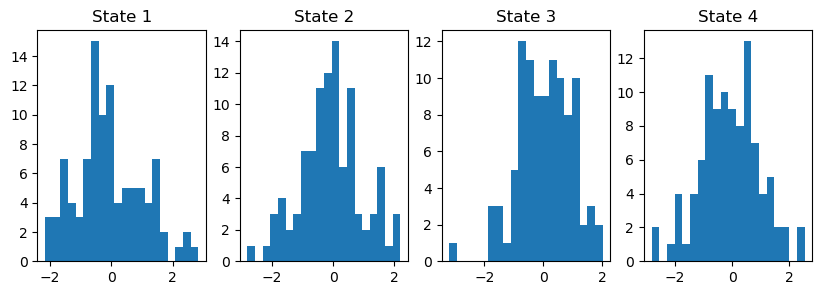

In [92]:
state_dim = 4
n_states = 100

dt = 0.01
u = jnp.array([1e-3, 2.0])

keys = [jax.random.PRNGKey(0)]  # seed 0
states = []

for i in range(n_states):
    # Generate a new key and random number each loop
    # Uniform in [0, 1) and standard normal
    states.append( jax.random.normal(keys[i], shape=(4,)) )
    _, new_key = jax.random.split(keys[i])  # split to get a new key for kp1 call
    keys.append(new_key)

states = jnp.array(states)
# print(states.shape)
# print(states[0,:])

# check state distributions to verify random generation
fig, axes = plt.subplots(1,4,figsize=(10,3))
for i in range(state_dim):
    axes[i].hist(states[:,i], bins=20)
    axes[i].set_title(f"State {i+1}")


J_batch_analytical = jax.vmap(discrete_jacobians_analytical, (0,None,None)) # map over state
A_k_analytical, B_k_analytical = J_batch_analytical(states, u, dt)

J_A_jax = jax.jacobian(unicycle_dynamics_dt, argnums=(0)) # take jacobian w.r.t. the state (first arg)
J_B_jax = jax.jacobian(unicycle_dynamics_dt, argnums=(1)) # take jacobian w.r.t. the control (second arg)
J_A_batch_jax = jax.vmap(J_A_jax, (0,None,None)) # map over states only
J_B_batch_jax = jax.vmap(J_B_jax, (0,None,None)) # map over states only
A_k_jax = J_A_batch_jax(states, u, dt)
B_k_jax = J_B_batch_jax(states, u, dt)

if jnp.allclose(A_k_analytical, A_k_jax):
    print("A's are good LETS GOOOOOOO")
else:
    print("NNNOOOOOOOOO (A's are bad)")


if jnp.allclose(B_k_analytical, B_k_jax):
    print("B's are good LETS GOOOOOOO")
else:
    print("NNNOOOOOOOOO (B's are bad)")


# debug...
print("Batched Jax & Analytical Jacobian Shapes:\t", B_k_jax.shape, B_k_analytical.shape)
print("Jax:\n", B_k_jax[0,:,:])
print("Analytical:\n", B_k_analytical[0,:,:])
# print(jnp.allclose(computed_jacobian_batch_analytical[100,:,:], computed_jacobian_batch_jax[100,:,:]))
# print(jnp.where(computed_jacobian_batch_analytical != computed_jacobian_batch_jax))



### 2. Study the classical cart-pole system and understand the limits of linearization. 
(This problem is adapted from [Underactuated Robotics notes](https://underactuated.csail.mit.edu/acrobot.html#cart_pole) by Russ Tedrake at MIT.) 
The cart-pole system is a classic example of a nonlinear system $\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x}, \mathbf{u})$.  Using the same convention as the textbook, we describe the state of the cart-pole as the vector $\mathbf{x}=[x,\theta, \dot{x}, \dot{\theta}]^T$, the dimension is $n=4$, and let the force on the cart be the control input $\mathbf{u}=[f_x]$, where the dimension is $m=1$. For sake of simplicity, let $m_\mathrm{c}=m_\mathrm{p}=\ell=1$ and $g=9.81$.



#### (a)
Let $\bar{\mathbf{x}} = \mathbf{x} - \mathbf{x}^*$, $\bar{\mathbf{u}}=\mathbf{u} - \mathbf{u}^*$ denote the error in state and control relative to the *equilibrium* $(\mathbf{x}^*, \mathbf{u}^*)$. Show that the linearized *error dynamics* is of the form


$$
\dot{\bar{\mathbf{x}}} \approx \mathbf{f}_\mathrm{lin}(\bar{\mathbf{x}},\bar{\mathbf{u}}) = A_\mathrm{lin}\bar{\mathbf{x}} + B_\mathrm{lin}\bar{\mathbf{u}}$$

where 

$$
A_\mathrm{lin}= \left[\nabla_\mathbf{x}f_1(\mathbf{x}^*,\mathbf{u}^*), \nabla_\mathbf{x}f_2(\mathbf{x}^*,\mathbf{u}^*),...,\nabla_\mathbf{x}f_n(\mathbf{x}^*,\mathbf{u}^*)\right]^T,
$$

$$
B_\mathrm{lin} = \left[\nabla_\mathbf{u}f_1(\mathbf{x}^*,\mathbf{u}^*), \nabla_\mathbf{u}f_2(\mathbf{x}^*,\mathbf{u}^*),...,\nabla_\mathbf{u}f_n(\mathbf{x}^*,\mathbf{u}^*)\right]^T.
$$ 

*Hint*: Since $(\mathbf{x}^*, \mathbf{u}^*)$ is an equilibrium point, $\mathbf{f}(\mathbf{x}^*, \mathbf{u}^*)=0$ and $\dot{\mathbf{x}}^*=0$.

### Answer:

We can take the Taylor expansion of f(x,u) around a point $(\mathbf{x}^*, \mathbf{u}^*)$:

$$f(\mathbf{x}, \mathbf{u}) \approx f(\mathbf{x}^*, \mathbf{u}^*) + \nabla_\mathbf{x} f(\mathbf{x}^*, \mathbf{u}^*)^\top (\mathbf{x} - \mathbf{x}^*) + \nabla_\mathbf{u} f(\mathbf{x}^*, \mathbf{u}^*)^\top (\mathbf{u} - \mathbf{u}^*) + \cdots$$

where the Jacobian is defined by stacking the gradients of each component $f_i$:

$$J_f(\mathbf{x}^*, \mathbf{u}^*) = \begin{bmatrix} \nabla_\mathbf{x} f_1^\top & \nabla_\mathbf{u} f_1^\top \\ \vdots & \vdots \\ \nabla_\mathbf{x} f_n^\top & \nabla_\mathbf{u} f_n^\top \end{bmatrix} \bigg|_{(\mathbf{x}^*, \mathbf{u}^*)}$$

Rearranging to isolate the constant terms:

$$f(\mathbf{x}, \mathbf{u}) \approx \underbrace{\nabla_\mathbf{x} f(\mathbf{x}^*, \mathbf{u}^*)^\top}_{A_\text{lin}} \mathbf{x} + \underbrace{\nabla_\mathbf{u} f(\mathbf{x}^*, \mathbf{u}^*)^\top}_{B_\text{lin}} \mathbf{u} + \underbrace{f(\mathbf{x}^*, \mathbf{u}^*) - \nabla_\mathbf{x} f(\mathbf{x}^*, \mathbf{u}^*)^\top \mathbf{x}^* - \nabla_\mathbf{u} f(\mathbf{x}^*, \mathbf{u}^*)^\top \mathbf{u}^*}_{\text{const.}}$$

Since $(\mathbf{x}^*, \mathbf{u}^*)$ is an equilibrium point, $\dot{\mathbf{x}}^* = 0$ (it is constant) and $f(\mathbf{x}^*, \mathbf{u}^*) = 0$, so the constant term vanishes. Substituting $\delta{\mathbf{x}} = \mathbf{x} - \mathbf{x}^*$ and $\delta{\mathbf{u}} = \mathbf{u} - \mathbf{u}^*$:

$$\delta{\dot{\mathbf{x}}} = \dot{\mathbf{x}} - \dot{\mathbf{x}}^* = f(\mathbf{x}, \mathbf{u}) - 0 \approx A_\text{lin}(\mathbf{x} - \mathbf{x}^*) + B_\text{lin}(\mathbf{u} - \mathbf{u}^*) = A_\text{lin}\delta{\mathbf{x}} + B_\text{lin}\delta{\mathbf{u}}$$

where:
$$A_\text{lin} = \begin{bmatrix} \nabla_\mathbf{x} f_1(\mathbf{x}^*, \mathbf{u}^*)^\top \\ \vdots \\ \nabla_\mathbf{x} f_n(\mathbf{x}^*, \mathbf{u}^*)^\top \end{bmatrix}, \qquad B_\text{lin} = \begin{bmatrix} \nabla_\mathbf{u} f_1(\mathbf{x}^*, \mathbf{u}^*)^\top \\ \vdots \\ \nabla_\mathbf{u} f_n(\mathbf{x}^*, \mathbf{u}^*)^\top \end{bmatrix}$$


#### (b)
The linearization error is given by $e(\mathbf{x}, \mathbf{u},\mathbf{x}^*, \mathbf{u}^*) = \| \mathbf{f}(\mathbf{x}, \mathbf{u}) - \mathbf{f}_\mathrm{lin}(\bar{\mathbf{x}}, \bar{\mathbf{u}})\|_2$. 
Compute the linearization error for the following states and control pairs. Include the numbers in your write-up.

- $\mathbf{x}=[0, 0.99\pi, 0, 0]^T$ and $\mathbf{u}=[0]$
- $\mathbf{x}=[0, 0.9\pi, 0, 0]^T$ and $\mathbf{u}=[-10]$
- $\mathbf{x}=[0, 0.85\pi, 0, 0]^T$ and $\mathbf{u}=[0]$
- $\mathbf{x}=[0, 0.5\pi, 0, 0]^T$ and $\mathbf{u}=[0]$
- $\mathbf{x}=[0, 0, 0, 0]^T$ and $\mathbf{u}=[0]$
- $\mathbf{x}=[1, \pi, 0, 0]^T$ and $\mathbf{u}=[10]$



In [116]:
def cart_pole_dynamics(state, control, params):
    m_c = params['m_c']
    m_p = params['m_p']
    l = params['l']
    g = params['g']

    x, theta, x_dot, theta_dot = state
    f_x = jnp.squeeze(control)  # always scalar regardless of input shape

    
    denom = m_c + m_p * jnp.sin(theta)**2
    
    x_ddot     = (1 / denom) * (f_x + m_p * jnp.sin(theta) * (l * theta_dot**2 + g * jnp.cos(theta)))
    theta_ddot = (1 / (l * denom)) * (-f_x * jnp.cos(theta) - m_p * l * theta_dot**2 * jnp.cos(theta) * jnp.sin(theta) - (m_c + m_p) * g * jnp.sin(theta))

    return jnp.array([x_dot, theta_dot, x_ddot, theta_ddot])


def cart_pole_linearized_dynamics(delta_state, delta_control, params):
    """
    Uses linearized cart pole "error dynamics" to compute x_dot.
    Assumes parameters are 1 except g = 9.81
    """
    cp_dynamics = functools.partial(cart_pole_dynamics, params=params)
    x_bar = params['x_bar'] # state at point of linearization
    u_bar = params['u_bar'] # control at point of linearization

    J_A = jax.jacobian(cp_dynamics, 0)
    A = J_A(x_bar, u_bar)

    J_B = jax.jacobian(cp_dynamics, 1)
    B = J_B(x_bar, u_bar)

    x_dot = A@delta_state + B@delta_control

    return x_dot


def get_linearization_error(f, f_lin, state, control, params):
    """
    Compute linearization error
    x_bar and u_bar (in params) are the point that f_lin was linearized about
    """
    x_bar = params['x_bar'] # state at point of linearization
    u_bar = params['u_bar'] # control at point of linearization
    delta_x = state - x_bar
    delta_u = control - u_bar

    x_dot = f(state, control, params)
    x_dot_lin = f_lin(delta_x, delta_u, params)

    err = jnp.linalg.norm(x_dot - x_dot_lin)

    return err


cart_pole_params = {
    'm_c': 1.0,
    'm_p': 1.0,
    'l': 1.0,
    'g': 9.81,
    'x_bar': jnp.array([0.0, jnp.pi, 0.0, 0.0]), # equilibrium state
    'u_bar': jnp.array([0.0]) # equilibrium control
}


xs = jnp.array([
    [0, 0.99*jnp.pi, 0, 0],
    [0, 0.9*jnp.pi,  0, 0],
    [0, 0.85*jnp.pi, 0, 0],
    [0, 0.5*jnp.pi,  0, 0],
    [0, 0.5*jnp.pi,  0, 0],
    [0, 0,           0, 0],
    [1, jnp.pi,      0, 0],
])

us = jnp.array([0.0, -10.0, 0.0, 0.0, -10, 0.0, 10.0])

errors = []
for x, u in zip(xs, us):
    err = get_linearization_error(cart_pole_dynamics, cart_pole_linearized_dynamics, x, u, cart_pole_params)
    # print(x, u)
    errors.append(err)

print("Errors: ")
for err in errors:
    print(err)

Errors: 
0.0008710865005520218
2.3539783215917636
2.288633458121908
26.054407411977905
37.12287359408248
68.91343251150953
2.5121479338940403e-15



#### (c)
Provide a brief answer to the following questions.

- Is our linear approximation valid for all the points we tested? 
- Do we expect a linear controller to do a decent job when $\theta=\frac{\pi}{2}$? 
- When $\theta$ is different from $\pi$, does the linearization error depend on $\mathbf{u}$?
- Why is the error from the second case bigger than the one from the third, even if the second $\theta$ is closer to $\pi$?
- What about the position $x$ of the cart? Should it affect the linearization error? If no, why not?

### Answer:
- The linear approximation is good for the first and last test point, when the state is near the state we linearized about.
- A linear controller would NOT do good when $\theta=\frac{\pi}{2}$. The error at that point was 26.
- The linearization error does seem to depend on $\mathbf{u}$ when $\theta$ is different from $\pi$.
- The error is larger in the second case than the third because there is a force (-10) pushing the cart to the left, and the pole is tilted to the right, so it would get pushed away from equilibrium.
- The position should NOT affect the linearization because the none of the dynamics depend on x. Velocity affects $\dot{\theta}$, but translation does not as long as velocity is constant


## Optimization

### 1. Cross entropy method. 
Study the cross-entropy method (CEM) as presented in the [Algorithms for Optimization textbook](https://algorithmsbook.com/optimization/files/optimization.pdf), focusing especially on page 133. Your objective is to implement the core CEM algorithm for use in global optimization, specifically targeting the Branin function described below.

Your implementation should include a function named `cross_entropy_method(...)`. At a minimum, this function must:
- Accept the objective function to optimize,
- Accept any required arguments for initializing the CEM algorithm,
- Accept algorithm-specific hyperparameters,
- Return the best solution found by the algorithm.

Write your code with clear, comprehensive comments that demonstrate a solid understanding of each algorithmic step.

To demonstrate both the correctness and generality of your implementation, apply your `cross_entropy_method` to at least one additional objective function beyond the Branin function.

For deeper analysis, visualize CEM’s progress and sample distributions over iterations using plots or animations.

Finally, create several GIFs that show how samples evolve and converge over time under differing hyperparameter settings and objective functions. Comment on the effectiveness of CEM for locating local versus global minima, and discuss which factors (such as population size, number of elite samples, initialization, etc.) should be considered when selecting hyperparameters for different optimization scenarios.

#### Branin function
The Branin function is a popular benchmark function for optimization algorithms. It is defined as:

$$
f(x, y) = a(y - bx^2 + cx - r)^2 + s(1 - t)\cos(x) + s
$$

where the typical parameter values are:
   - $ a = 1 $
   - $ b = \frac{5.1}{4\pi^2} $
   - $ c = \frac{5}{\pi} $
   - $ r = 6 $
   - $ s = 10 $
   - $ t = \frac{1}{8\pi} $

The function is usually evaluated on the domain $ x \in [-5, 10] $ and $ y \in [0, 15] $.

The Branin function has three global minima, making it useful for testing the performance of global optimization algorithms. Its landscape is characterized by multiple valleys and ridges, which can challenge optimization methods.



In [ ]:
def branin_func(xy):
    x, y = xy[..., 0], xy[..., 1]
    a, b, c, r, s, t = 1, 5.1/(4*jnp.pi**2), 5/jnp.pi, 6, 10, 1/(8*jnp.pi)
    return a*(y - b*x**2 + c*x - r)**2 + s*(1-t)*jnp.cos(x) + s

def rosenbrock_func(xy):
    x, y = xy[..., 0], xy[..., 1]
    return (1 - x)**2 + 100*(y - x**2)**2


def cross_entropy_method(
    f,                  # objective function: R^d -> R (to be minimized)
    mu_init,            # initial mean of sampling distribution, shape (d,)
    sigma_init,         # initial std dev (scalar or shape (d,)), applied per-dimension
    n_samples,          # number of samples drawn each iteration (population size)
    n_elite,            # number of top samples used to refit the distribution
    n_iters,            # total number of CEM iterations
    key,                # jax.random.PRNGKey for reproducibility
):
    """
    Cross-Entropy Method for continuous global optimization (Algorithm 8.2,
    Algorithms for Optimization, Kochenderfer & Wheeler).

    At each iteration:
      1. Sample N candidates from the current Gaussian N(mu, diag(sigma^2))
      2. Evaluate the objective on all candidates
      3. Keep the top-k (elite) candidates with lowest objective value
      4. Refit mu and sigma to the elite set (MLE of Gaussian = sample mean/std)
      5. Repeat until convergence or max iterations

    Returns:
      mu_best  : best mean found (shape d,)
      history  : list of dicts with per-iteration info for visualization
    """
    d   = len(mu_init)
    mu  = jnp.array(mu_init, dtype=float)
    sig = jnp.ones(d) * sigma_init if jnp.isscalar(sigma_init) else jnp.array(sigma_init, dtype=float)

    history = []

    for i in range(n_iters):
        # Split key for this iteration
        key, subkey = jax.random.split(key)

        # Step 1: Sample from current distribution N(mu, diag(sig^2))
        # Each dimension sampled independently (diagonal covariance)
        samples = mu + sig * jax.random.normal(subkey, shape=(n_samples, d))

        # Step 2: Evaluate objective on all samples
        scores = f(samples)  # shape (n_samples,)

        # Step 3: Select elite samples (lowest objective = best)
        elite_idx     = jnp.argsort(scores)[:n_elite]
        elite_samples = samples[elite_idx]

        # Step 4: Refit distribution to elite samples (MLE Gaussian)
        mu  = elite_samples.mean(axis=0)   # new mean = sample mean of elites
        sig = elite_samples.std(axis=0)    # new std  = sample std  of elites
        sig = jnp.maximum(sig, 1e-6)       # numerical floor to avoid collapse

        history.append({
            'iter':          i,
            'mu':            mu,
            'sigma':         sig,
            'samples':       samples,
            'elite_samples': elite_samples,
            'best_score':    scores[elite_idx[0]],
        })

    return mu, history

# disclaimer: AI (Claude) helped make the visualization code
import ipywidgets as widgets
from IPython.display import display
import matplotlib.animation as animation
from matplotlib.patches import Ellipse

def make_cem_widget(history, f, xlim, ylim, title, n_contour=200):
    """
    Interactive CEM visualization using ipywidgets.
    Use the slider or play button to scrub through iterations.
    """
    gx = jnp.linspace(*xlim, n_contour)
    gy = jnp.linspace(*ylim, n_contour)
    GX, GY = jnp.meshgrid(gx, gy)
    grid   = jnp.stack([GX, GY], axis=-1)
    Z      = f(grid)

    def draw_frame(iter_idx):
        h = history[iter_idx]
        mu, sig    = h['mu'], h['sigma']
        samples    = h['samples']
        elite      = h['elite_samples']

        fig, ax = plt.subplots(figsize=(7, 5))
        ax.contourf(GX, GY, Z, levels=40, cmap='viridis', alpha=0.7)
        ax.contour( GX, GY, Z, levels=15, colors='white', linewidths=0.4, alpha=0.5)

        ax.scatter(samples[:, 0], samples[:, 1], s=6,  color='white', alpha=0.35, label='Samples')
        ax.scatter(elite[:, 0],   elite[:, 1],   s=18, color='red',   alpha=0.8,  label='Elite')
        ax.scatter(*mu, s=150, color='yellow', marker='*', zorder=5,
                   label=f'μ  (f={h["best_score"]:.4f})')

        ellipse = Ellipse(xy=mu, width=2*sig[0], height=2*sig[1],
                          edgecolor='yellow', fc='None', lw=2, linestyle='--')
        ax.add_patch(ellipse)

        ax.set_xlim(xlim); ax.set_ylim(ylim)
        ax.set_title(f'{title}  —  iter {iter_idx+1}/{len(history)}')
        ax.legend(loc='upper right', fontsize=8)
        ax.set_xlabel('x'); ax.set_ylabel('y')
        plt.tight_layout()
        plt.show()

    play = widgets.Play(
        value=0, min=0, max=len(history)-1, step=1,
        interval=300,          # ms between frames when playing
        description='Play',
    )
    slider = widgets.IntSlider(
        value=0, min=0, max=len(history)-1, step=1,
        description='Iteration',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='500px'),
    )
    widgets.jslink((play, 'value'), (slider, 'value'))  # keep play and slider in sync

    ui = widgets.HBox([play, slider])
    out = widgets.interactive_output(draw_frame, {'iter_idx': slider})
    display(ui, out)

def plot_convergence(histories, labels, title):
    """Plot best score vs iteration for multiple runs."""
    fig, ax = plt.subplots(figsize=(7, 4))
    for h, lbl in zip(histories, labels):
        scores = [frame['best_score'] for frame in h]
        ax.plot(scores, label=lbl)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Best elite score')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig

# Run tests

# Test 1: Branin, large population
mu_best_branin, hist_branin = cross_entropy_method(
    f=branin_func, mu_init=[0.0, 7.5], sigma_init=5.0,
    n_samples=200, n_elite=20, n_iters=30,
    key=jax.random.PRNGKey(0),
)
print(f"Branin best:  x={mu_best_branin},  f={branin_func(mu_best_branin[None])[0]:.5f}")

# Test 2: Branin, small population (risks missing global min)
_, hist_branin_small = cross_entropy_method(
    f=branin_func, mu_init=[0.0, 7.5], sigma_init=5.0,
    n_samples=30, n_elite=5, n_iters=30,
    key=jax.random.PRNGKey(0),
)

# Test 3: Rosenbrock
mu_best_rosen, hist_rosen = cross_entropy_method(
    f=rosenbrock_func, mu_init=[0.0, 0.0], sigma_init=2.0,
    n_samples=300, n_elite=30, n_iters=40,
    key=jax.random.PRNGKey(1),
)
print(f"Rosenbrock best:  x={mu_best_rosen},  f={rosenbrock_func(mu_best_rosen[None])[0]:.5f}")

# Convergence plot
fig = plot_convergence(
    [hist_branin, hist_branin_small, hist_rosen],
    ['Branin (n=200, k=20)', 'Branin (n=30, k=5)', 'Rosenbrock (n=300, k=30)'],
    title='CEM convergence across experiments'
)
fig.savefig('convergence.png', dpi=120, bbox_inches='tight')
plt.close()


# Display widgets for each test
print("=== Branin (large population) ===")
make_cem_widget(hist_branin,       branin_func,     xlim=(-5,10), ylim=(0,15),
                title='Branin (n=200, k=20)')

print("=== Branin (small population) ===")
make_cem_widget(hist_branin_small, branin_func,     xlim=(-5,10), ylim=(0,15),
                title='Branin (n=30, k=5)')

print("=== Rosenbrock ===")
make_cem_widget(hist_rosen,        rosenbrock_func, xlim=(-2,2),  ylim=(-1,3),
                title='Rosenbrock (n=300, k=30)')

Branin best:  x=[3.14159272 2.27499996],  f=0.39789
Rosenbrock best:  x=[0.72097543 0.51975844],  f=0.07785
=== Branin (large population) ===


Output()

=== Branin (small population) ===


Output()

=== Rosenbrock ===


Output()

### Analysis

#### Local vs. global minima
CEM, if given a large sigma (wide distribution) relative to the domain of the function, is effective at finding a global minimum. If there are many valleys on the domain, more elite samples will be needed to explore and compare each of the valleys. If the population size or number of elite samples is not large enough, the algorithm could find a local minimum that is not the global minimum and move towards it without being able to effectivel explore the rest of the domain.

#### Hyperparameter considerations
Other hyperparameters like the number of iterations may waste computing power if the algorithm cannot converge. In general, for most of the parameters and hyperparameters for this algorithm, the larger they are, the more robust the algorithm is at finding a global minimum, but it comes at the cost of compute.



### 2. Gradient descent. 
Given the different functions studied in notebook 02, discuss how the choice of initial conditions and step size affects the convergence and the final solution when using (vanilla) gradient descent. Provide some plots to support your discussion. 

Larger step size makes the algorithm faster, but it may never converge because it can step over the minimum its trying to find. The initial condition matters a lot, because the gradient descent will march towards the nearest local minimum. The only way to find a global minimum is if you choose an initial guess where that global minimum is the closest local minimum. The image below shows this clearly.

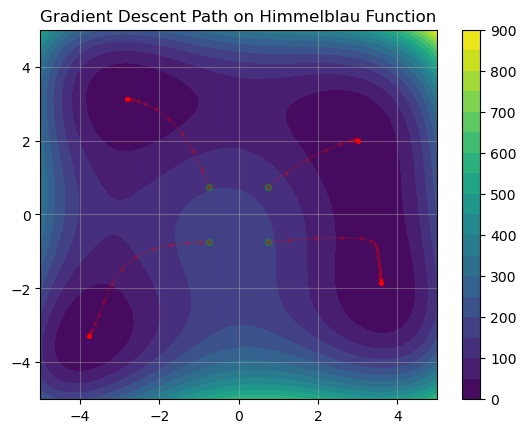


## Control Certificates

### 1. Class-K function
Consider a class-$\mathcal{K}$ function of the form $\alpha(z) = a z$. Explain how adjusting the parameter $a$ impacts both the system's response and the level of conservatism inherent in a Control Barrier Function (CBF) safety filter. Specifically, discuss the trade-offs associated with choosing higher versus lower values of $a$ in terms of safety margin, responsiveness, and potential limitations for practical implementation.

### Answer:
If you increase a, you make the function less conservative and allow the state to go towards the barrier more quickly. This may be more dangerous in real life scenarios, but the system may be able to track a desired control much better (a higher performing response). Decreasing a has the oppositve effect. It may be more safe, but the system will not track the desired control as closely.




### 2. Class-K function and control actuation limits.
When implementing a CBF safety filter using a class-$\mathcal{K}$ function $\alpha(z) = a z$, how should actuator constraints—such as control saturation or rate limits—influence your selection of the parameter $a$? Address how such constraints can limit the allowable range of $a$, and describe the potential consequences of choosing an inappropriate value in the presence of these practical limitations.

### Answer:

If you have a higher a, you are requiring your actuators to be able to "turn" the state away form the barrier more quickly. If your actuators can't keep up, you risk driving your system into an unsafe state. With weaker actuators, you need a smaller a.




### 3. High-order CBF.


### Answer:

#### (a)

$$
\dot{z} = f(z) + g(z)u
$$
$$f(z) = \begin{bmatrix} v\cos\theta \\ v\sin\theta \\ 0 \\ 0 \end{bmatrix}, \qquad g(z) = \begin{bmatrix} 0 & 0 \\ 0 & 0 \\ 1 & 0 \\ 0 & 1 \end{bmatrix}$$

\begin{align*}
\mathcal{L}_f b(z) &= \nabla b(z) \cdot f(z) = 2x(v\cos\theta) + 2y(v\sin\theta) = 2v(x\cos\theta + y\sin\theta) \\[0.5em]
\mathcal{L}_g(\mathcal{L}_f b(z)) &= \nabla(2v(x\cos\theta + y\sin\theta)) \cdot g(z) \nonumber \\
&= \begin{bmatrix} 2v\cos\theta, & 2v\sin\theta, & 2v(-x\sin\theta + y\cos\theta), & 2(x\cos\theta + y\sin\theta) \end{bmatrix} \begin{bmatrix} 0 & 0 \\ 0 & 0 \\ 1 & 0 \\ 0 & 1 \end{bmatrix} \nonumber \\
&= \begin{bmatrix} 2v(-x\sin\theta + y\cos\theta) & 2v(x\cos\theta + y\sin\theta) \end{bmatrix} \neq 0 \\[0.5em]
\mathcal{L}_g(\mathcal{L}_f^0 b(z)) &= \mathcal{L}_g(b(z)) = \nabla b \cdot g = \begin{bmatrix} 2x, & 2y, & 0, & 0 \end{bmatrix} \cdot g = 0
\end{align*}

$$\boxed{m_r = 2}$$

#### (b)
 The control input needs to appear in the constraint for us to be able to implement it in a CBF-QP safety filter. For a quadratic program, we have:
$$
\begin{align*}
\nabla b(z) f(z, u) &\geq -\alpha(b(z)) \nonumber \\
\Rightarrow \mathcal{L}_f b + \underbrace{\mathcal{L}_g b}_{\to\, 0} \cdot u &\geq -\alpha(b)
\end{align*}
$$
so the $u$ term goes away. We cannot use a standard CBF-QP filter.


### 4. Closer look at CBF-CLF-QP Filter demo.

a. For the Higher-Order CBF constraint, when we plug in $y=0$, $\theta=0$, $x=-7$,
$\mathcal{L}_g \mathcal{L}_f b(z) = [0, -14]$. $\omega$ does not appear in the constraint.
The constraint can be satisfied only by braking, but then the system never reaches the goal.

b. The $\alpha$ value being decreased means the system reacts more slowly to being near the barrier. The large step size also makes it so that the system risks crossing the barrier before being able to turn away.

